# Classification of Music by Genre

## Part 2: Neural-Networks

### 2.0.0. Imports Used in This Notebook:

In [1]:
import matplotlib.pyplot as plt

import numpy as np, pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import time


2026-09-08 11:46:23.620657: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2.0.1. Reusable Helper Methods Used in This Notebook:

In [2]:
# Reusable evaluation: returns one results row in the same schema as all_results.csv
def evaluate_keras_model(fitted_model, X_te, y_te, name, training_time, tuning_time=np.nan):
    y_prob = fitted_model.predict(X_te, verbose=0)      # softmax scores, needed for AUC
    y_pred = np.argmax(y_prob, axis=1)                  # hard labels, needed for everything else
    y_bin = label_binarize(y_te, classes=range(num_classes))
    row = pd.DataFrame({
        'Model': [name],
        'Family': ['Neural Network'],
        'Test Accuracy': [accuracy_score(y_te, y_pred)],
        'Precision (macro)': [precision_score(y_te, y_pred, average='macro')],
        'Recall (macro)': [recall_score(y_te, y_pred, average='macro')],
        'F1 (macro)': [f1_score(y_te, y_pred, average='macro')],
        'Macro AUC': [roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')],
        'Micro AUC': [roc_auc_score(y_bin, y_prob, average='micro')],
        'Training Time (s)': [training_time],
        'Tuning Time (s)': [tuning_time],
        'Complexity': [fitted_model.count_params()],
        'Complexity Measure': ['trainable parameters']
    })
    return row, y_pred, y_prob


# Reusable: confusion matrix plus one-vs-rest ROC curves for any model's predictions
def plot_confusion_and_roc(y_true, y_pred, y_prob, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labelencoder.classes_,
                                            xticks_rotation=45, cmap='Blues', ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    plt.show()

    # One binary column per class: 1 where the true label is that class, 0 otherwise
    y_bin = label_binarize(y_true, classes=range(num_classes))

    plt.figure(figsize=(8, 6))
    for i, label in enumerate(labelencoder.classes_):
        # Class i treated as positive, all other genres as negative
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr_i, tpr_i, label=f'{label} (AUC = {auc(fpr_i, tpr_i):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')          # chance line for reference
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{title}: One-vs-Rest ROC Curves'); plt.legend(fontsize=8)
    plt.show()

    print(f'macro_auc = {roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr"):.4f}')
    print(f'micro_auc = {roc_auc_score(y_bin, y_prob, average="micro"):.4f}')

### 2.1.  Basic Feed-Forward Neural Network:

In [3]:


# Same GTZAN feature table used in Part 1, so results are comparable
df = pd.read_csv('GTZAN_Data_Music_Genre_Classification/features_30_sec.csv')
# df = df.drop(columns=['filename']).drop_duplicates().dropna()
df = df.drop(columns=['filename'])
df = df.drop(columns=[c for c in df.columns if df[c].nunique() == 1])  # drop constant cols
X = df.iloc[:, :-1].astype('float32')    # numeric audio features
y = df.iloc[:, -1]                       # genre label (text)

labelencoder = LabelEncoder()            # blues -> 0, classical -> 1, ...
y = labelencoder.fit_transform(y)
num_classes = len(labelencoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()                # NN training needs scaled inputs
X_train = scaler.fit_transform(X_train).astype('float32')
X_test = scaler.transform(X_test).astype('float32')
print(f'X_train.shape = {X_train.shape}')
print(f'X_test.shape = {X_test.shape}')
print(f'num_classes = {num_classes}')
print(f'labelencoder.classes_ = {labelencoder.classes_}')

X_train.shape = (800, 58)
X_test.shape = (200, 58)
num_classes = 10
labelencoder.classes_ = ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


### 2.1.1.  Basic Feed-Forward Network: Define and Compile:

In [4]:
# Basic feed-forward net: 58 features -> 256 -> 128 -> 10 genres, with dropout

tf.keras.utils.set_random_seed(42)   # same seed convention as Part 1

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
print(f'total_params = {model.count_params()}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,290 (192.54 KB)

 Trainable params: 49,290 (192.54 KB)

 Non-trainable params: 0 (0.00 B)

total_params = 49290


### 2.1.2.  Basic Feed-Forward Neural Network: Training the Model:

In [5]:
# Train with early stopping on a validation split, timed like the Part 1 models


early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

nn_start_time = time.time()
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=200,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=0)
nn_end_time = time.time()
nn_training_time = nn_end_time - nn_start_time

print(f'NN training time = {nn_training_time:.2f} seconds')
print(f'epochs_run = {len(history.history["loss"])}')


NN training time = 5.29 seconds
epochs_run = 35


### 2.1.3. Basic Feed-Forward Neural Network: Learning Curves:

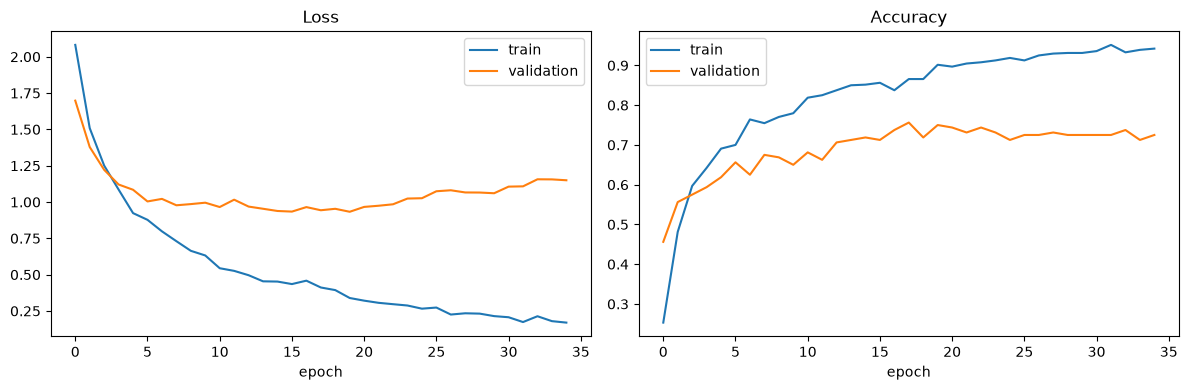

best_epoch = 20 of 35
val_accuracy_at_best_epoch = 0.7500


In [6]:
# Learning curves: check for overfitting and confirm early stopping chose a sensible epoch


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
print(f'best_epoch = {best_epoch} of {len(history.history["loss"])}')
print(f'val_accuracy_at_best_epoch = {history.history["val_accuracy"][best_epoch - 1]:.4f}')


### 2.1.4. Basic Feed-Forward Neural Network: Predictions:

In [7]:
# Predict on the untouched test set (mirrors Part 1 sections 1.1.2 - 1.1.3)
from sklearn.metrics import accuracy_score

y_pred_nn = np.argmax(model.predict(X_test, verbose=0), axis=1)
train_accuracy_nn = accuracy_score(y_train, np.argmax(model.predict(X_train, verbose=0), axis=1))
nn_accuracy = accuracy_score(y_test, y_pred_nn)

print(f'Predictions shape = {y_pred_nn.shape}')
print(f'First 10 predicted = {y_pred_nn[:10]}')
print(f'First 10 actual    = {y_test[:10]}')
print(f'NN Training accuracy = {train_accuracy_nn:.4f}')
print(f'NN Testing accuracy  = {nn_accuracy:.4f}')

Predictions shape = (200,)
First 10 predicted = [1 0 3 5 0 9 2 2 4 5]
First 10 actual    = [1 0 6 5 0 2 9 2 4 5]
NN Training accuracy = 0.9213
NN Testing accuracy  = 0.7750


### 2.1.5. Basic Feed-Forward Neural Network: Precision, Recall, F1:

In [8]:
# Macro precision, recall, F1 and confusion matrix (mirrors Part 1 sections 1.1.4 - 1.1.5)
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay

nn_precision = precision_score(y_test, y_pred_nn, average='macro')
nn_recall    = recall_score(y_test, y_pred_nn, average='macro')
nn_f1        = f1_score(y_test, y_pred_nn, average='macro')

print(f'nn_precision = {nn_precision:.4f}')
print(f'nn_recall    = {nn_recall:.4f}')
print(f'nn_f1        = {nn_f1:.4f}')

nn_precision = 0.7790
nn_recall    = 0.7750
nn_f1        = 0.7715


## 2.1.6. Basic Feed-Forward Neural Network: Confusion Matrix:

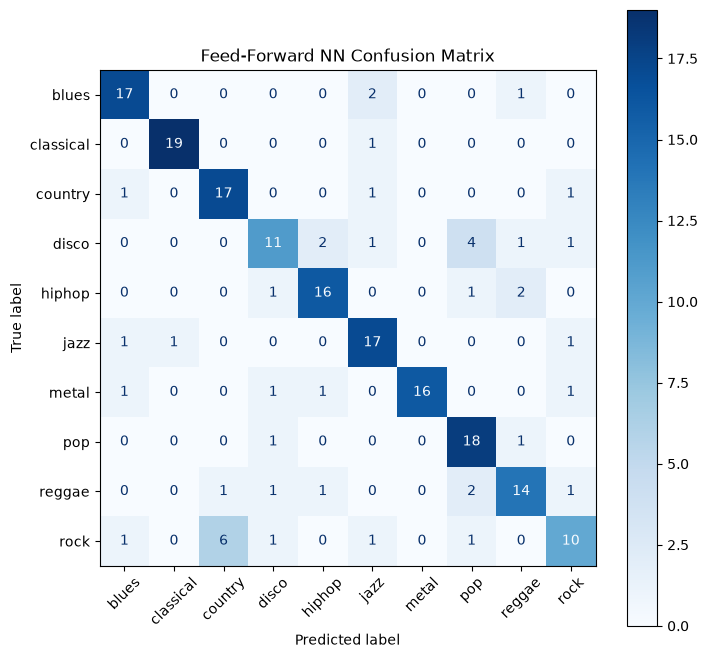

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn, display_labels=labelencoder.classes_,
                                        xticks_rotation=45, cmap='Blues', ax=ax)
ax.set_title('Feed-Forward NN Confusion Matrix')
plt.show()

### 2.1.7. Basic Feed-Forward Neural Network: ROC curves and macro/micro AUC

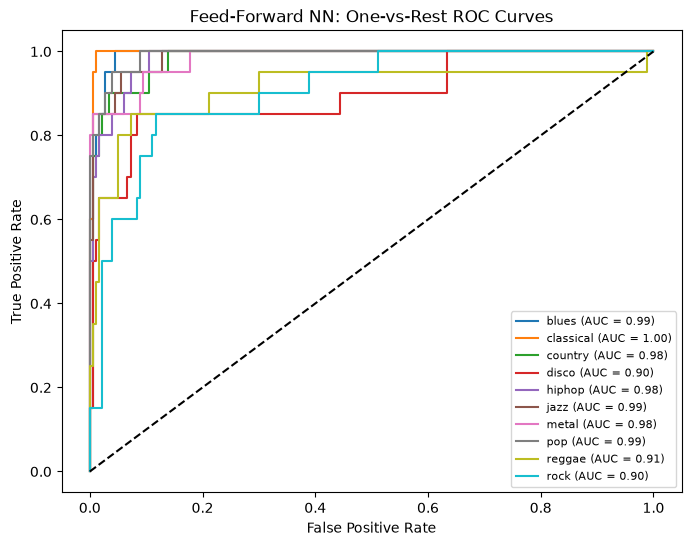

roc_auc_macro_nn = 0.9623
roc_auc_micro_nn = 0.9648


In [10]:
# One-vs-rest ROC curves and macro/micro AUC (mirrors Part 1 section 1.1.6)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

y_score_nn = model.predict(X_test, verbose=0)
y_test_bin = label_binarize(y_test, classes=range(num_classes))

fpr_nn, tpr_nn, roc_auc_nn = {}, {}, {}
for i in range(num_classes):
    fpr_nn[i], tpr_nn[i], _ = roc_curve(y_test_bin[:, i], y_score_nn[:, i])
    roc_auc_nn[i] = auc(fpr_nn[i], tpr_nn[i])

plt.figure(figsize=(8, 6))
for i, label in enumerate(labelencoder.classes_):
    plt.plot(fpr_nn[i], tpr_nn[i], label=f'{label} (AUC = {roc_auc_nn[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Feed-Forward NN: One-vs-Rest ROC Curves'); plt.legend(fontsize=8)
plt.show()

roc_auc_macro_nn = roc_auc_score(y_test_bin, y_score_nn, average='macro', multi_class='ovr')
roc_auc_micro_nn = roc_auc_score(y_test_bin, y_score_nn, average='micro')
print(f'roc_auc_macro_nn = {roc_auc_macro_nn:.4f}')
print(f'roc_auc_micro_nn = {roc_auc_micro_nn:.4f}')

### Store Results So Far to File (Part 1 + Feed-Forward NN):

In [11]:
# Bank the feed-forward results in the same schema as part1_results.csv
part1_results = pd.read_csv('part1_results.csv')

nn_row = pd.DataFrame({
    'Model': ['Feed-Forward NN'],
    'Family': ['Neural Network'],
    'Test Accuracy': [nn_accuracy],
    'Precision (macro)': [nn_precision],
    'Recall (macro)': [nn_recall],
    'F1 (macro)': [nn_f1],
    'Macro AUC': [roc_auc_macro_nn],
    'Micro AUC': [roc_auc_micro_nn],
    'Training Time (s)': [nn_training_time],
    'Tuning Time (s)': [np.nan],
    'Complexity': [model.count_params()],
    'Complexity Measure': ['trainable parameters']
})

results = pd.concat([part1_results, nn_row], ignore_index=True)
results.to_csv('all_results.csv', index=False)
print(f'results.shape = {results.shape}')
results

results.shape = (5, 12)


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,SVM,Classical ML,0.765,0.768611,0.765,0.764319,0.943611,0.945317,0.032251,11.890773,38454,support vectors x features
1,Random Forest,Classical ML,0.820,0.820470,0.820,0.818040,0.975306,0.976993,0.497786,106.945784,75074,decision nodes
2,k-NN,Classical ML,0.690,0.707873,0.690,0.690255,0.905028,0.905900,0.002672,0.396208,800,stored samples
3,Gradient Boosting,Classical ML,0.795,0.802499,0.795,0.794836,0.978222,0.978806,9.974431,3234.812495,2076,decision nodes
4,Feed-Forward NN,Neural Network,0.775,0.779030,0.775,0.771468,0.962278,0.964769,5.291497,NaN,49290,trainable parameters


### NOTE: Comparisons to Part 1 Algorithms:

The above Basic Feed-Forward Neural Network reaches 0.775 with 49,290 parameters in 6 seconds versus Random Forest (see Part 1 notebook file) which reached 0.820 with 75,074 decision nodes.

The 0.92 versus 0.775 train-test gap points to data volume as the binding constraint.


## 2.1.8. Basic Feed-Forward Neural Network: Hyper-Parameter Tuning:

In [12]:
# Parameterized feed-forward builder; defaults reproduce the 2.1.1 architecture exactly
def build_ffnn(hidden=(256, 128), dropout=0.3, learning_rate=1e-3):
    tf.keras.utils.set_random_seed(42)
    ffnn = models.Sequential([layers.Input(shape=(X_train.shape[1],))])
    for units in hidden:
        ffnn.add(layers.Dense(units, activation='relu'))
        ffnn.add(layers.Dropout(dropout))
    ffnn.add(layers.Dense(num_classes, activation='softmax'))
    ffnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    return ffnn

In [13]:
# Compare feed-forward configurations on a fixed validation set (parallels GridSearchCV in Part 1).
# A single held-out split, rather than Keras's validation_split, so every config sees the same data.
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                            random_state=42, stratify=y_train)

ffnn_grid = [
    {'hidden': (128,),            'dropout': 0.3, 'learning_rate': 1e-3},
    {'hidden': (256, 128),        'dropout': 0.3, 'learning_rate': 1e-3},   # the 2.1 baseline
    {'hidden': (256, 128),        'dropout': 0.5, 'learning_rate': 1e-3},
    {'hidden': (512, 256),        'dropout': 0.5, 'learning_rate': 3e-4},
    {'hidden': (512, 256, 128),   'dropout': 0.5, 'learning_rate': 3e-4},
]

rows = []
ffnn_tuning_start_time = time.time()
for i, cfg in enumerate(ffnn_grid):
    candidate = build_ffnn(**cfg)                    # fresh weights every iteration
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    h = candidate.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                      epochs=200, batch_size=32, callbacks=[es], verbose=0)
    best = int(np.argmin(h.history['val_loss']))     # the epoch whose weights were restored
    rows.append({'idx': i, 'hidden': str(cfg['hidden']), 'dropout': cfg['dropout'],
                 'learning_rate': cfg['learning_rate'],
                 'val_accuracy': h.history['val_accuracy'][best],
                 'epochs_run': len(h.history['loss']),
                 'params': candidate.count_params()})
ffnn_tuning_time = time.time() - ffnn_tuning_start_time

ffnn_tuning_results = pd.DataFrame(rows).sort_values('val_accuracy', ascending=False)
print(f'ffnn_tuning_time = {ffnn_tuning_time:.2f} seconds')
ffnn_tuning_results

ffnn_tuning_time = 42.42 seconds


,idx,hidden,dropout,learning_rate,val_accuracy,epochs_run,params
1,1,"(256, 128)",0.3,0.0010,0.76875,34,49290
0,0,"(128,)",0.3,0.0010,0.76250,48,8842
3,3,"(512, 256)",0.5,0.0003,0.76250,66,164106
4,4,"(512, 256, 128)",0.5,0.0003,0.75625,72,195722
2,2,"(256, 128)",0.5,0.0010,0.74375,37,49290


In [14]:
# Selection uses validation accuracy only -- the test set stays untouched until now
best_idx = int(ffnn_tuning_results.iloc[0]['idx'])
best_cfg = ffnn_grid[best_idx]
print(f'best_cfg = {best_cfg}')

ffnn_tuned = build_ffnn(**best_cfg)
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

tuned_start_time = time.time()
tuned_history = ffnn_tuned.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                               epochs=200, batch_size=32, callbacks=[es], verbose=0)
tuned_training_time = time.time() - tuned_start_time

nn_tuned_row, y_pred_nn_tuned, y_score_nn_tuned = evaluate_keras_model(
    ffnn_tuned, X_test, y_test, 'Feed-Forward NN (tuned)',
    tuned_training_time, tuning_time=ffnn_tuning_time)
nn_tuned_row

best_cfg = {'hidden': (256, 128), 'dropout': 0.3, 'learning_rate': 0.001}


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,Feed-Forward NN (tuned),Neural Network,0.755,0.759568,0.755,0.753195,0.957889,0.961458,5.39108,42.418918,49290,trainable parameters


## 2.2. CNN using Spectrogram Images:

### 2.2.1. CNN: Load spectrogram image files for use in training:

In [15]:
# Load the pre-rendered mel spectrogram PNGs, cropping off the matplotlib padding
import os, glob
from PIL import Image

IMG_DIR = 'GTZAN_Data_Music_Genre_Classification/images_original'
CROP = (54, 35, 390, 253)      # left, top, right, bottom -> the 336 x 218 plot area
IMG_SIZE = (128, 128)          # CNN input size

paths, labels = [], []
for genre in sorted(labelencoder.classes_):
    for p in sorted(glob.glob(os.path.join(IMG_DIR, genre, '*.png'))):
        paths.append(p)
        labels.append(genre)

X_img = np.stack([np.asarray(Image.open(p).convert('RGB').crop(CROP).resize(IMG_SIZE),
                             dtype='float32') / 255.0 for p in paths])
y_img = labelencoder.transform(labels)

# X_img_train, X_img_test, y_img_train, y_img_test = train_test_split(
#     X_img, y_img, test_size=0.2, random_state=42, stratify=y_img)

# print(f'X_img.shape = {X_img.shape}')
# print(f'y_img.shape = {y_img.shape}')
# print(f'files_per_genre = {np.bincount(y_img)}')
# print(f'X_img_train.shape = {X_img_train.shape}')
# print(f'X_img_test.shape = {X_img_test.shape}')

# Reproduce the exact 800/200 song split used in Part 1 and section 2.1
csv_path = 'GTZAN_Data_Music_Genre_Classification/features_30_sec.csv'

# Read just the filename column; its row order matches the X and y built in section 2.1
song_names = pd.read_csv(csv_path)['filename']

# Same test_size, seed and stratify vector as 2.1, so sklearn assigns the identical
# rows to each side -- only the payload being split differs (names instead of features)
names_train, names_test = train_test_split(song_names, test_size=0.2,
                                           random_state=42, stratify=y)

# Filename formats differ between the two sources: 'blues.00000.wav' -> 'blues00000.png'
# The second replace drops only the FIRST dot, which is the one after the genre
to_png = lambda n: n.replace('.wav', '.png').replace('.', '', 1)
train_pngs, test_pngs = set(names_train.map(to_png)), set(names_test.map(to_png))

# 'paths' was built in the loading loop above; reduce each full path to its bare filename
img_files = np.array([os.path.basename(p) for p in paths])

# Boolean masks pick out the image rows whose song belonged to each side of the split
train_mask = np.array([f in train_pngs for f in img_files])
test_mask  = np.array([f in test_pngs  for f in img_files])

X_img_train, y_img_train = X_img[train_mask], y_img[train_mask]
X_img_test,  y_img_test  = X_img[test_mask],  y_img[test_mask]

print(f'X_img_train.shape = {X_img_train.shape}')
print(f'X_img_test.shape = {X_img_test.shape}')
print(f'songs_without_an_image = {len(song_names) - train_mask.sum() - test_mask.sum()}')

X_img_train.shape = (799, 128, 128, 3)
X_img_test.shape = (200, 128, 128, 3)
songs_without_an_image = 1


### NOTE: training data and test data split should now be identical to that used in Part 1 and the basic NN above in 2.1

In [16]:
# The image arrays arrive in genre order, so Keras's validation_split would slice an
# unshuffled tail and hand back only the last genre or two. Carve out a stratified
# validation set explicitly instead; 2.2 and 2.3 both train against this same split.
X_img_tr, X_img_val, y_img_tr, y_img_val = train_test_split(
    X_img_train, y_img_train, test_size=0.2, random_state=42, stratify=y_img_train)

print(f'X_img_tr.shape = {X_img_tr.shape}')
print(f'X_img_val.shape = {X_img_val.shape}')
print(f'val_class_counts = {np.bincount(y_img_val)}')   # expect 16 songs per genre

X_img_tr.shape = (639, 128, 128, 3)
X_img_val.shape = (160, 128, 128, 3)
val_class_counts = [16 16 16 16 16 16 16 16 16 16]


### 2.2.2. CNN using Spectrograms: Build the Network:

In [32]:
# This includes a fix seen in initial development / debugging,
# for an issue which may have been caused by batch normalization
def build_cnn(dropout=0.3, learning_rate=3e-4, bn_momentum=0.9):
    tf.keras.utils.set_random_seed(42)
    cnn = models.Sequential([layers.Input(shape=X_img_train.shape[1:])])
    for filters in (32, 64, 128, 256):
        cnn.add(layers.Conv2D(filters, 3, padding='same', activation='relu'))
        # 639 images at batch 32 gives only ~20 updates per epoch, so Keras's default
        # BN momentum of 0.99 leaves the moving mean/variance stale and inference collapses.
        # 0.9 lets them converge within the epochs this dataset actually affords.
        cnn.add(layers.BatchNormalization(momentum=bn_momentum))
        cnn.add(layers.MaxPooling2D())
    cnn.add(layers.GlobalAveragePooling2D())
    cnn.add(layers.Dropout(dropout))
    cnn.add(layers.Dense(num_classes, activation='softmax'))
    cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
    return cnn

### 2.2.3. CNN using Spectrograms: Training and Timing:

In [33]:
# Genre-ordered arrays break Keras's validation_split, which slices the tail without shuffling.
# Carve out a stratified validation set explicitly instead.
X_img_tr, X_img_val, y_img_tr, y_img_val = train_test_split(
    X_img_train, y_img_train, test_size=0.2, random_state=42, stratify=y_img_train)

print(f'X_img_tr.shape = {X_img_tr.shape}')
print(f'X_img_val.shape = {X_img_val.shape}')
print(f'val_class_counts = {np.bincount(y_img_val)}')

cnn = build_cnn()

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

cnn_start_time = time.time()
cnn_history = cnn.fit(X_img_tr, y_img_tr,
                      validation_data=(X_img_val, y_img_val),
                      epochs=100,
                      batch_size=32,
                      callbacks=[early_stop_cnn],
                      verbose=0)
cnn_end_time = time.time()
cnn_training_time = cnn_end_time - cnn_start_time
cnn_best_epoch = int(np.argmin(cnn_history.history['val_loss'])) + 1

print(f'cnn_training_time = {cnn_training_time:.2f} seconds')
print(f'cnn_epochs_run = {len(cnn_history.history["loss"])}')
print(f'cnn_best_epoch = {cnn_best_epoch}')
print(f'cnn_val_accuracy_at_best_epoch = {cnn_history.history["val_accuracy"][cnn_best_epoch - 1]:.4f}')

X_img_tr.shape = (639, 128, 128, 3)
X_img_val.shape = (160, 128, 128, 3)
val_class_counts = [16 16 16 16 16 16 16 16 16 16]
cnn_training_time = 605.58 seconds
cnn_epochs_run = 44
cnn_best_epoch = 29
cnn_val_accuracy_at_best_epoch = 0.7312


### 2.2.4: CNN: Learning Curves:

final_train_accuracy = 0.9984
final_val_accuracy = 0.7375
final_train_loss = 0.0143
final_val_loss = 0.8646


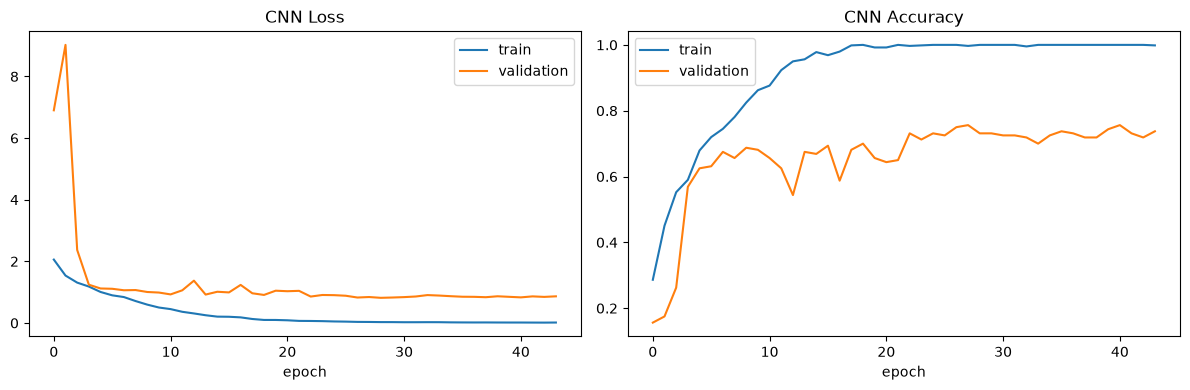

In [19]:
print(f'final_train_accuracy = {cnn_history.history["accuracy"][-1]:.4f}')
print(f'final_val_accuracy = {cnn_history.history["val_accuracy"][-1]:.4f}')
print(f'final_train_loss = {cnn_history.history["loss"][-1]:.4f}')
print(f'final_val_loss = {cnn_history.history["val_loss"][-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history.history['loss'], label='train')
axes[0].plot(cnn_history.history['val_loss'], label='validation')
axes[0].set_title('CNN Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(cnn_history.history['accuracy'], label='train')
axes[1].plot(cnn_history.history['val_accuracy'], label='validation')
axes[1].set_title('CNN Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [34]:
# Confirm bug fix. There should be a roughly even split among classes, not a large number in one class
print(f'pred_class_counts = {np.bincount(np.argmax(cnn.predict(X_img_val, verbose=0), axis=1), minlength=10)}')

# Same images, but forcing batch statistics instead of the moving averages
print(f'training_mode_val_accuracy = {(np.argmax(cnn(X_img_val, training=True).numpy(), axis=1) == y_img_val).mean():.4f}')

pred_class_counts = [15 19 17 13 13 13 16 16 16 22]
training_mode_val_accuracy = 0.7312


### 2.2.5. CNN: Predicitions, Precision, Recall, F1:

In [21]:
# 
# Get the test set numbers in the way that other models were scored on
#

cnn_row, y_pred_cnn, y_score_cnn = evaluate_keras_model(
    cnn, X_img_test, y_img_test, 'CNN (spectrograms)', cnn_training_time)
cnn_row

,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN (spectrograms),Neural Network,0.785,0.788506,0.785,0.783391,0.9645,0.968469,691.003241,NaN,392906,trainable parameters


### 2.2.6. CNN: Confusion Matrix, ROC, and AUC:

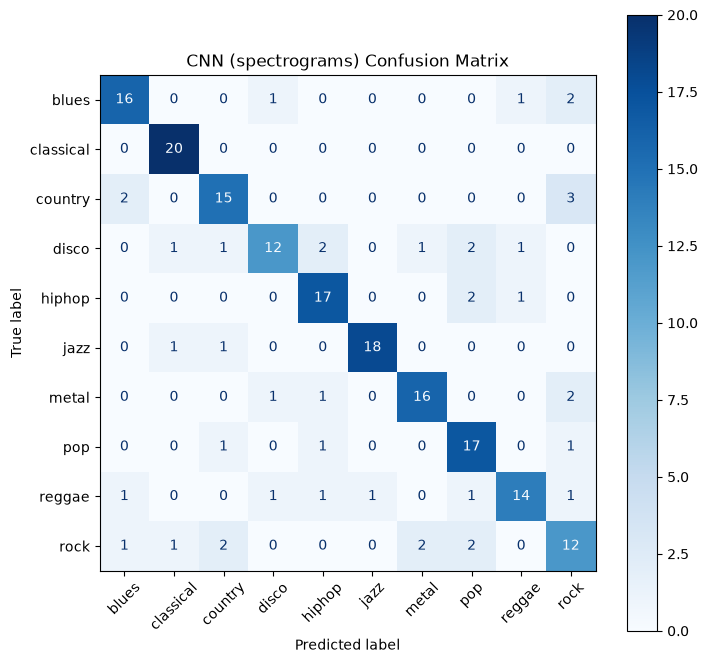

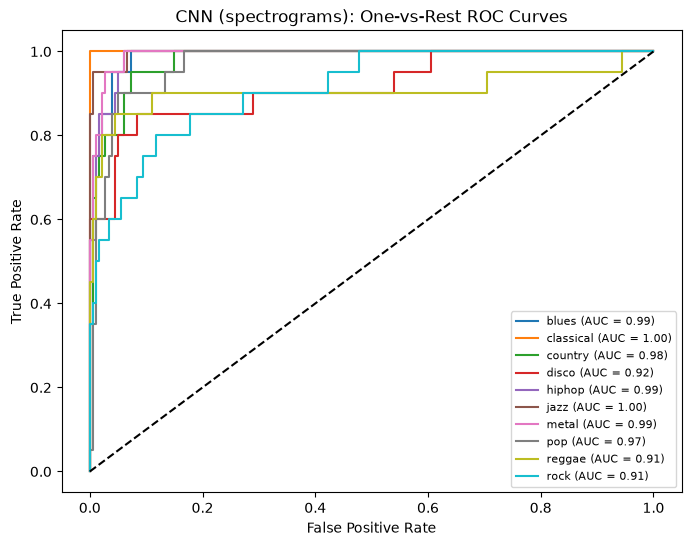

macro_auc = 0.9645
micro_auc = 0.9685


In [22]:
plot_confusion_and_roc(y_img_test, y_pred_cnn, y_score_cnn, 'CNN (spectrograms)')

## Summary So Far:

On the identical 200 test songs, the CNN reaches:

* 0.785 accuracy
* 0.7885 macro precision
* 0.785 recall
* 0.7834 macro F1,
* and 0.9645 macro AUC

using 392,906 parameters and 606.8 seconds of training.

The full ranking is now:

1. random forest 0.820
2. gradient boosting 0.795
3. CNN 0.785
4. feed-forward net 0.775
5. SVM 0.765
6. k-NN 0.690

The CNN edges past the feed-forward net by one percentage point, but NOTE: one point on 200 samples is two songs, and the standard error is around 2.9 points, so in fact the two neural models are statistically indistinguishable.

Speed of training: the CNN took 607 seconds versus the feed-forward net's 6 — an increase by a 100 multiple in training time, with only a difference of two correctly classified tracks. And both still lose to a random forest that trained in half a second.

The CNN's macro AUC of 0.9645 is also below both tree approaches.

Does increasing model complexity actually improve performance? on this dataset, no, and the reason is data volume rather than architecture.

A batch normalization bug in first definition of CNN model building made it appear to be a 10% random classifier.

### 2.2.7. CNN with Augmentation

Generatie additional training examples by applying transformations to the ones we already have, chosen so the transformation changes the input without changing the correct label. The model then never sees the exact same image twice, which makes it much harder for it to succeed by memorizing individual training examples and pushes it toward features that survive the perturbations.

In [35]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_H, IMG_W = X_img_tr.shape[1], X_img_tr.shape[2]

def time_augment(img, label, min_frac=0.8, time_width=16, n_masks=2):
    # random slice along time only, then stretch back -- all 128 frequency rows kept
    w  = tf.cast(tf.round(tf.random.uniform([], min_frac, 1.0) * IMG_W), tf.int32)
    x0 = tf.random.uniform([], 0, IMG_W - w + 1, dtype=tf.int32)
    img = tf.image.resize(img[:, x0:x0 + w, :], (IMG_H, IMG_W))

    # optional: blank a few short time spans (set n_masks=0 to skip entirely)
    for _ in range(n_masks):
        size  = tf.random.uniform([], 1, time_width + 1, dtype=tf.int32)
        start = tf.random.uniform([], 0, IMG_W - size, dtype=tf.int32)
        idx   = tf.range(IMG_W)
        keep  = tf.cast(tf.logical_or(idx < start, idx >= start + size), img.dtype)
        img   = img * tf.reshape(keep, [1, -1, 1])

    return tf.ensure_shape(img, (IMG_H, IMG_W, 3)), label


train_ds = (tf.data.Dataset.from_tensor_slices((X_img_tr, y_img_tr))
            .shuffle(len(X_img_tr), seed=42)
            .map(time_augment, num_parallel_calls=AUTOTUNE)
            .batch(32)
            .prefetch(AUTOTUNE))

cnn_aug = build_cnn()          # unchanged builder, same seed, same init

early_stop_aug = EarlyStopping(monitor='val_loss', patience=25,
                               restore_best_weights=True)

aug_start_time = time.time()
aug_history = cnn_aug.fit(train_ds,
                          validation_data=(X_img_val, y_img_val),
                          epochs=200,
                          callbacks=[early_stop_aug],
                          verbose=0)
aug_training_time = time.time() - aug_start_time

/Users/brian/envs/py312/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


#### 2.2.7.1. CNN with Augmentation: Evaluation, Accuracy:

In [44]:
aug_best_epoch = int(np.argmin(aug_history.history['val_loss'])) + 1
print(f'aug_training_time = {aug_training_time:.2f} seconds')
print(f'aug_epochs_run = {len(aug_history.history["loss"])}')
print(f'aug_best_epoch = {aug_best_epoch}')
print(f'aug_val_accuracy_at_best_epoch = {aug_history.history["val_accuracy"][aug_best_epoch - 1]:.4f}')
print(f'final_train_accuracy = {aug_history.history["accuracy"][-1]:.4f}')

cnn_aug_row, y_pred_aug, y_score_aug = evaluate_keras_model(
    cnn_aug, X_img_test, y_img_test, 'CNN (augmented)', aug_training_time)
cnn_aug_row

aug_training_time = 942.07 seconds
aug_epochs_run = 70
aug_best_epoch = 45
aug_val_accuracy_at_best_epoch = 0.7312
final_train_accuracy = 0.9969


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN (augmented),Neural Network,0.74,0.75158,0.74,0.740263,0.959556,0.962861,942.071224,NaN,392906,trainable parameters


In [45]:
cnn_fixedcrop_row = cnn_aug_row.assign(Model='CNN (fixed crop)')

In [38]:
# one = tf.data.Dataset.from_tensor_slices((X_img_tr[:1], y_img_tr[:1])).map(time_augment)
# imgs = [next(iter(one))[0].numpy() for _ in range(3)]
# print([float(np.abs(imgs[0] - im).mean()) for im in imgs])

one = (tf.data.Dataset.from_tensor_slices((X_img_tr[:1], y_img_tr[:1]))
       .repeat(3)
       .map(time_augment))
imgs = [im.numpy() for im, _ in one]      # one iterator, three elements
print([float(np.abs(imgs[0] - im).mean()) for im in imgs])

[0.0, 0.07035507261753082, 0.06995087116956711]


2026-09-08 12:49:19.709105: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [39]:
rng = tf.random.Generator.from_seed(42)

def time_augment_version_2(img, label, min_frac=0.8, time_width=16, n_masks=2):
    w  = tf.cast(tf.round(rng.uniform([], min_frac, 1.0) * IMG_W), tf.int32)
    x0 = rng.uniform([], 0, IMG_W - w + 1, dtype=tf.int32)
    img = tf.image.resize(img[:, x0:x0 + w, :], (IMG_H, IMG_W))

    for _ in range(n_masks):
        size  = rng.uniform([], 1, time_width + 1, dtype=tf.int32)
        start = rng.uniform([], 0, IMG_W - size, dtype=tf.int32)
        idx   = tf.range(IMG_W)
        keep  = tf.cast(tf.logical_or(idx < start, idx >= start + size), img.dtype)
        img   = img * tf.reshape(keep, [1, -1, 1])

    return tf.ensure_shape(img, (IMG_H, IMG_W, 3)), label

In [40]:
train_ds = (tf.data.Dataset.from_tensor_slices((X_img_tr, y_img_tr))
            .shuffle(len(X_img_tr), seed=42)
            .map(time_augment_version_2, num_parallel_calls=AUTOTUNE)
            .batch(32)
            .prefetch(AUTOTUNE))

cnn_aug = build_cnn()          # unchanged builder, same seed, same init

early_stop_aug = EarlyStopping(monitor='val_loss', patience=25,
                               restore_best_weights=True)

aug_start_time = time.time()
aug_history = cnn_aug.fit(train_ds,
                          validation_data=(X_img_val, y_img_val),
                          epochs=200,
                          callbacks=[early_stop_aug],
                          verbose=0)
aug_training_time = time.time() - aug_start_time

/Users/brian/envs/py312/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


In [41]:
aug_best_epoch = int(np.argmin(aug_history.history['val_loss'])) + 1
print(f'aug_training_time = {aug_training_time:.2f} seconds')
print(f'aug_epochs_run = {len(aug_history.history["loss"])}')
print(f'aug_best_epoch = {aug_best_epoch}')
print(f'aug_val_accuracy_at_best_epoch = {aug_history.history["val_accuracy"][aug_best_epoch - 1]:.4f}')
print(f'final_train_accuracy = {aug_history.history["accuracy"][-1]:.4f}')

cnn_aug_row, y_pred_aug, y_score_aug = evaluate_keras_model(
    cnn_aug, X_img_test, y_img_test, 'CNN (augmented)', aug_training_time)
cnn_aug_row

aug_training_time = 942.07 seconds
aug_epochs_run = 70
aug_best_epoch = 45
aug_val_accuracy_at_best_epoch = 0.7312
final_train_accuracy = 0.9969


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN (augmented),Neural Network,0.74,0.75158,0.74,0.740263,0.959556,0.962861,942.071224,NaN,392906,trainable parameters


In [46]:
one = (tf.data.Dataset.from_tensor_slices((X_img_tr[:1], y_img_tr[:1]))
       .repeat(3)
       .map(time_augment_version_2))
imgs = [im.numpy() for im, _ in one]      # one iterator, three elements
print([float(np.abs(imgs[0] - im).mean()) for im in imgs])

[0.0, 0.06447599828243256, 0.06465695053339005]


2026-09-08 14:28:44.963431: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [47]:
ds = (tf.data.Dataset.from_tensor_slices((X_img_tr[:1], y_img_tr[:1]))
      .map(time_augment_version_2))
a = [im.numpy() for im, _ in ds][0]      # first pass
b = [im.numpy() for im, _ in ds][0]      # second pass, fresh iterator
print(float(np.abs(a - b).mean()))

0.08173524588346481


2026-09-08 14:29:31.888018: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-09-08 14:29:31.916051: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [48]:
aug_best_epoch = int(np.argmin(aug_history.history['val_loss'])) + 1
print(f'aug_training_time = {aug_training_time:.2f} seconds')
print(f'aug_epochs_run = {len(aug_history.history["loss"])}')
print(f'aug_best_epoch = {aug_best_epoch}')
print(f'aug_val_accuracy_at_best_epoch = {aug_history.history["val_accuracy"][aug_best_epoch - 1]:.4f}')
print(f'final_train_accuracy = {aug_history.history["accuracy"][-1]:.4f}')

cnn_aug_row, y_pred_aug, y_score_aug = evaluate_keras_model(
    cnn_aug, X_img_test, y_img_test, 'CNN (augmented)', aug_training_time)
cnn_aug_row

aug_training_time = 942.07 seconds
aug_epochs_run = 70
aug_best_epoch = 45
aug_val_accuracy_at_best_epoch = 0.7312
final_train_accuracy = 0.9969


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN (augmented),Neural Network,0.74,0.75158,0.74,0.740263,0.959556,0.962861,942.071224,NaN,392906,trainable parameters


### NOTE: Training accuracy went up slightly versus the frozen version's 0.9922. This was unexpected for augmentation. Genuine per-epoch augmentation didn't reduce memorization at all.

#### 2.2.7.2. CNN with Augmentation: Learning Curve:

final_train_accuracy = 0.9969
final_val_accuracy   = 0.7312
final_train_loss     = 0.0564
final_val_loss       = 1.0519


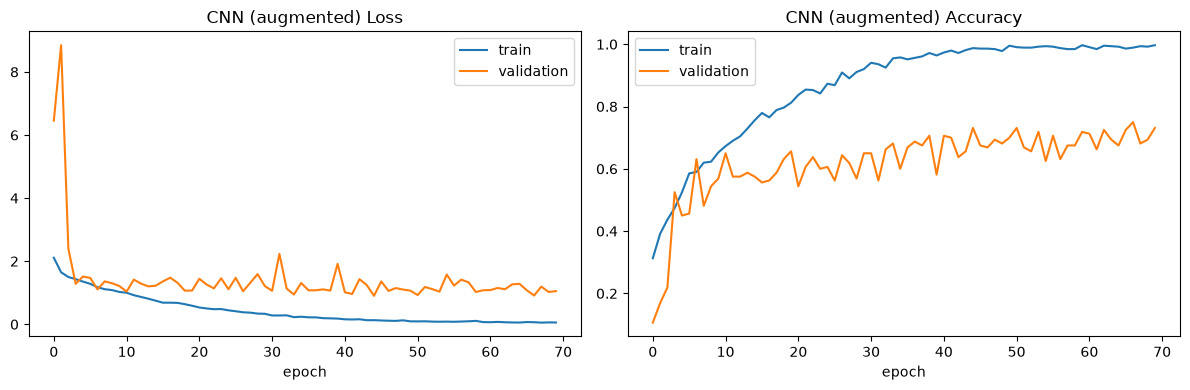

In [49]:
print(f'final_train_accuracy = {aug_history.history["accuracy"][-1]:.4f}')
print(f'final_val_accuracy   = {aug_history.history["val_accuracy"][-1]:.4f}')
print(f'final_train_loss     = {aug_history.history["loss"][-1]:.4f}')
print(f'final_val_loss       = {aug_history.history["val_loss"][-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(aug_history.history['loss'], label='train')
axes[0].plot(aug_history.history['val_loss'], label='validation')
axes[0].set_title('CNN (augmented) Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(aug_history.history['accuracy'], label='train')
axes[1].plot(aug_history.history['val_accuracy'], label='validation')
axes[1].set_title('CNN (augmented) Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

#### NOTE:

Augmentation slowed memorization but didn't prevent it. The baseline hit essentially perfect training accuracy by about epoch 17 and finished with training loss 0.0143; the augmented run took until roughly epoch 40 to get there and finished at 0.0564, four times higher, over 70 epochs instead of 44. The augmentations did make the training set harder to fit. But they didn't change the endpoint. Final training accuracy 0.9969 versus 0.9984, and validation accuracy 0.7312 versus 0.7375. The generalization gap is about 26 points either way.

Validation loss actually got worse, 1.0519 against 0.8646, and the augmented validation curves are visibly noisier, with spikes to 2.2 around epochs 30 and 40 and a persistent sawtooth in accuracy. Note that batch normalization accumulates its moving mean and variance from the training stream, which is now masked and time-stretched, while validation images are clean. That train-inference distribution mismatch inflates validation loss without changing accuracy significantly. This is similar to the momentum problem noted before.

Augmentation delayed convergence, cost 337 extra seconds, and left generalization unchanged. With 639 independent songs and 392,906 parameters, the network memorizes whatever it's shown, augmented or not.

#### 2.2.7.3. CNN (Augmented): Confusion Matrix, ROC, AUC:

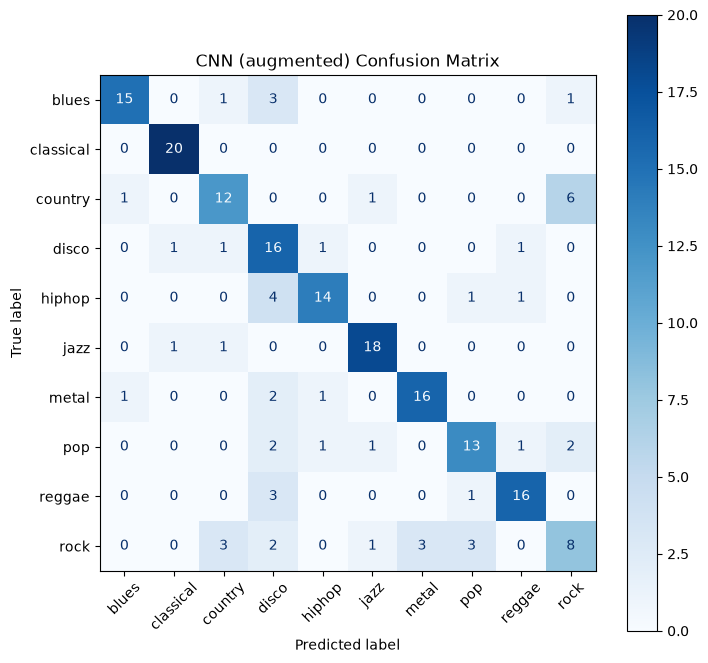

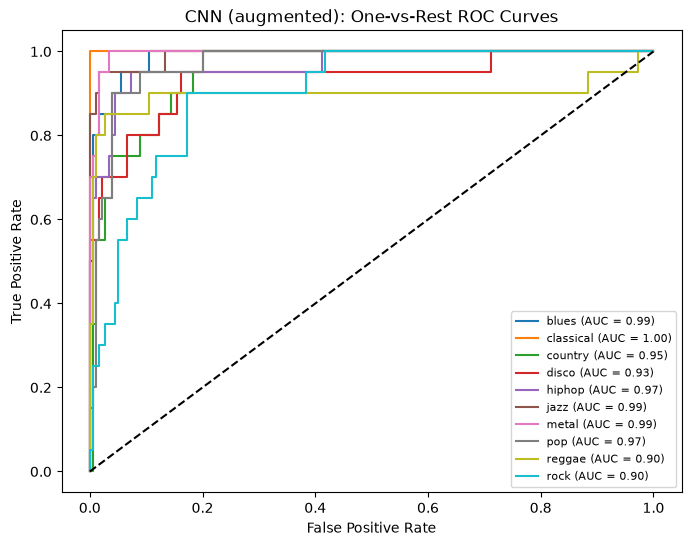

macro_auc = 0.9596
micro_auc = 0.9629


In [50]:
#
# Confusion Matrix and ROC
#

plot_confusion_and_roc(y_img_test, y_pred_aug, y_score_aug, 'CNN (augmented)')

## 2.3. CNN-LSTM (also using the same spectrogram arrays):

### 2.3.1. CNN-LSTM: Build the Model - Define and Compile:

In [23]:
# CNN-LSTM hybrid: convolutions extract local time-frequency features, then an LSTM
# reads them as a sequence along the time axis of the spectrogram
def build_cnn_lstm(lstm_units=64, dropout=0.3, learning_rate=3e-4, bn_momentum=0.9):
    tf.keras.utils.set_random_seed(42)

    inputs = layers.Input(shape=X_img_train.shape[1:])       # (freq=128, time=128, 3)
    x = inputs

    # Pool frequency aggressively but keep time resolution, so the LSTM gets enough steps.
    # The last block pools (4, 1): 4x on frequency, none on time.
    for filters, pool in [(32, (2, 2)), (64, (2, 2)), (128, (4, 1))]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization(momentum=bn_momentum)(x)
        x = layers.MaxPooling2D(pool)(x)

    # x is now (freq=8, time=32, 128). Swap axes so time is axis 1 -- the sequence dimension.
    x = layers.Permute((2, 1, 3))(x)                          # -> (time=32, freq=8, 128)

    # Flatten frequency and channels into one feature vector per time step
    x = layers.Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)   # -> (32, 1024)

    # Bidirectional so each time step sees context from both earlier and later in the track
    x = layers.Bidirectional(layers.LSTM(lstm_units))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    cnn_lstm = models.Model(inputs, outputs)
    cnn_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
    return cnn_lstm

cnn_lstm = build_cnn_lstm()
cnn_lstm.summary()
print(f'cnn_lstm_total_params = {cnn_lstm.count_params()}')

Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 32, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       557,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,002 (2.49 MB)

 Trainable params: 652,554 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

cnn_lstm_total_params = 653002


### 2.3.2. CNN-LSTM: Training:

In [24]:
# Train the hybrid, reusing the stratified validation split built in 2.2
early_stop_hybrid = EarlyStopping(monitor='val_accuracy', mode='max',
                                 patience=20, restore_best_weights=True)

hybrid_start_time = time.time()
hybrid_history = cnn_lstm.fit(X_img_tr, y_img_tr,
                              validation_data=(X_img_val, y_img_val),
                              epochs=100,
                              batch_size=32,
                              callbacks=[early_stop_hybrid],
                              verbose=0)
hybrid_end_time = time.time()
hybrid_training_time = hybrid_end_time - hybrid_start_time
hybrid_best_epoch = int(np.argmax(hybrid_history.history['val_accuracy'])) + 1

print(f'hybrid_training_time = {hybrid_training_time:.2f} seconds')
print(f'hybrid_epochs_run = {len(hybrid_history.history["loss"])}')
print(f'hybrid_best_epoch = {hybrid_best_epoch}')
print(f'hybrid_val_accuracy_at_best_epoch = {hybrid_history.history["val_accuracy"][hybrid_best_epoch - 1]:.4f}')

hybrid_training_time = 599.34 seconds
hybrid_epochs_run = 44
hybrid_best_epoch = 24
hybrid_val_accuracy_at_best_epoch = 0.6812


### 2.3.3. CNN-LSTM: Learning Curves:

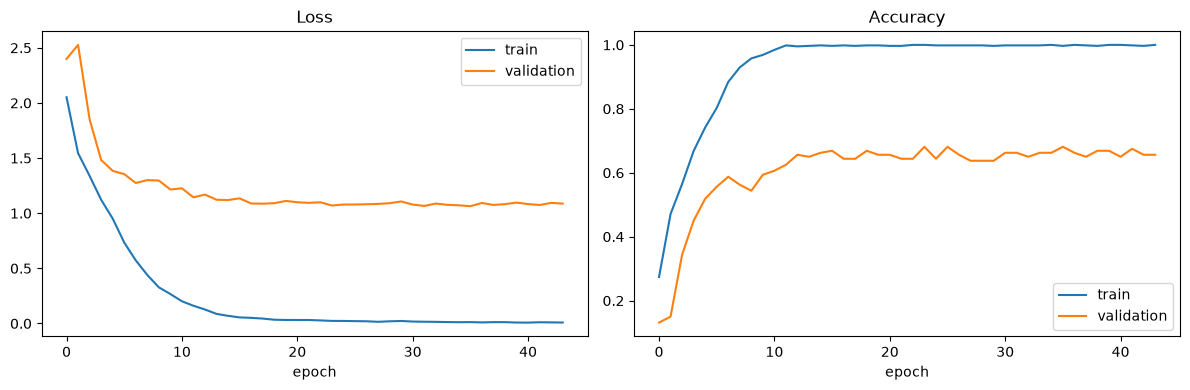

best_epoch = 24 of 44
val_accuracy_at_best_epoch = 0.6812


In [25]:
# Learning curves: check for overfitting and confirm early stopping chose a sensible epoch

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hybrid_history.history['loss'], label='train')
axes[0].plot(hybrid_history.history['val_loss'], label='validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(hybrid_history.history['accuracy'], label='train')
axes[1].plot(hybrid_history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'best_epoch = {hybrid_best_epoch} of {len(hybrid_history.history["loss"])}')
print(f'val_accuracy_at_best_epoch = {hybrid_history.history["val_accuracy"][hybrid_best_epoch - 1]:.4f}')

In [26]:
hybrid_row, y_pred_hybrid, y_score_hybrid = evaluate_keras_model(cnn_lstm, X_img_test, y_img_test, 'CNN-LSTM (spectrograms)', hybrid_training_time)
hybrid_row

,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,CNN-LSTM (spectrograms),Neural Network,0.7,0.700864,0.7,0.692958,0.939667,0.944347,599.338432,NaN,653002,trainable parameters


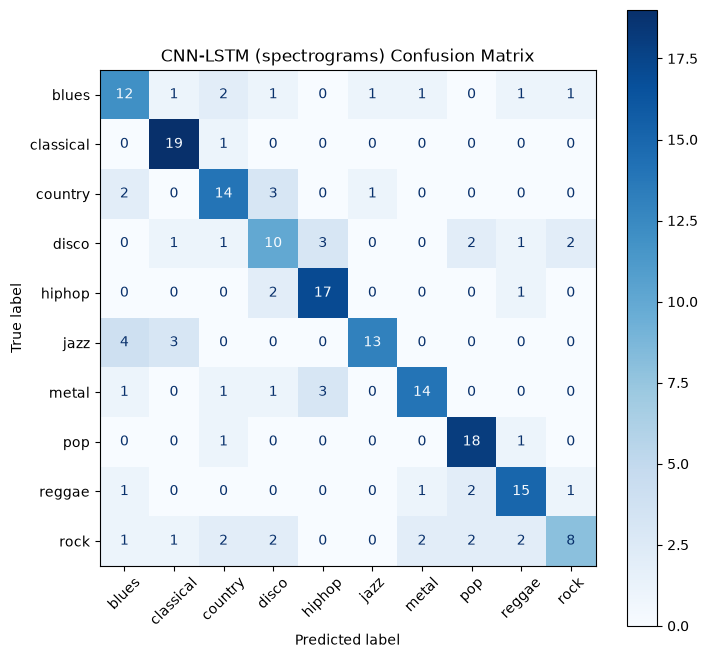

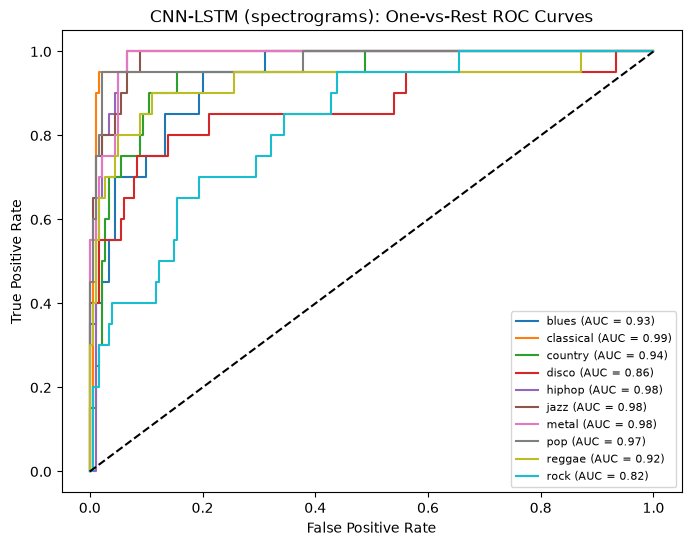

macro_auc = 0.9397
micro_auc = 0.9443


In [27]:
#
# Confusion Matrix and ROC
#

plot_confusion_and_roc(y_img_test, y_pred_hybrid, y_score_hybrid, 'CNN-LSTM (spectrograms)')

## 2.4. Comparison of Models:

### 2.4.1. Combined Table:

In [28]:
# Complete table

results = pd.concat([part1_results, nn_row, nn_tuned_row, cnn_row, hybrid_row],
                    ignore_index=True)
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results.to_csv('all_results.csv', index=False)
print(f'results.shape = {results.shape}')
results

results.shape = (8, 12)


,Model,Family,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Macro AUC,Micro AUC,Training Time (s),Tuning Time (s),Complexity,Complexity Measure
0,Random Forest,Classical ML,0.820,0.820470,0.820,0.818040,0.975306,0.976993,0.497786,106.945784,75074,decision nodes
1,Gradient Boosting,Classical ML,0.795,0.802499,0.795,0.794836,0.978222,0.978806,9.974431,3234.812495,2076,decision nodes
2,CNN (spectrograms),Neural Network,0.785,0.788506,0.785,0.783391,0.964500,0.968469,691.003241,NaN,392906,trainable parameters
3,Feed-Forward NN,Neural Network,0.775,0.779030,0.775,0.771468,0.962278,0.964769,5.291497,NaN,49290,trainable parameters
4,SVM,Classical ML,0.765,0.768611,0.765,0.764319,0.943611,0.945317,0.032251,11.890773,38454,support vectors x features
5,Feed-Forward NN (tuned),Neural Network,0.755,0.759568,0.755,0.753195,0.957889,0.961458,5.391080,42.418918,49290,trainable parameters
6,CNN-LSTM (spectrograms),Neural Network,0.700,0.700864,0.700,0.692958,0.939667,0.944347,599.338432,NaN,653002,trainable parameters
7,k-NN,Classical ML,0.690,0.707873,0.690,0.690255,0.905028,0.905900,0.002672,0.396208,800,stored samples


### 2.4.2. Comparison Charts:

# 2.4.2.1. Side-by-side accuracy and macro F1 for all eight models

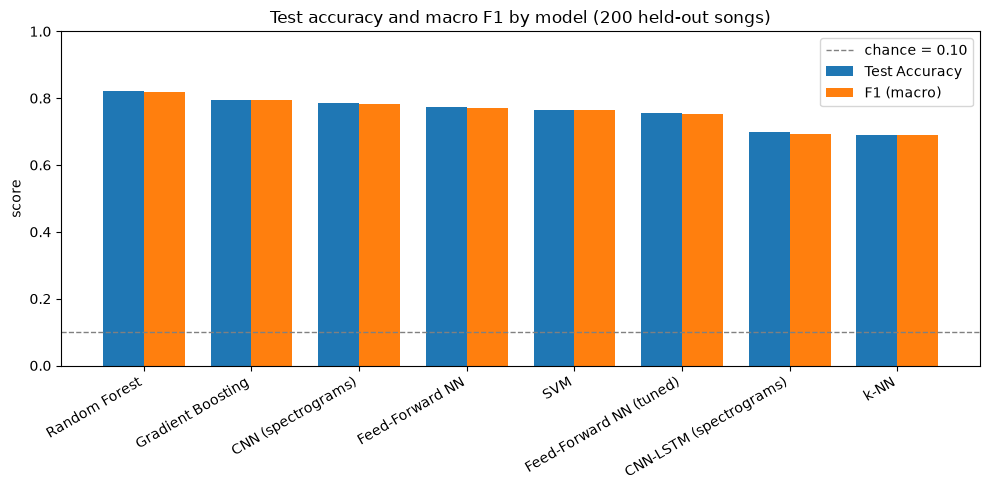

In [29]:
# 2.4.2.1. Side-by-side accuracy and macro F1 for all eight models

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results))    # one tick position per model, in ranked order
width = 0.38                   # leaves a visible gap between each accuracy/F1 pair

ax.bar(x - width/2, results['Test Accuracy'], width, label='Test Accuracy')
ax.bar(x + width/2, results['F1 (macro)'], width, label='F1 (macro)')

# 0.10 is what blind guessing would score on ten equally sized genres
ax.axhline(0.10, color='gray', linestyle='--', linewidth=1, label='chance = 0.10')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=30, ha='right')
ax.set_ylabel('score')
ax.set_ylim(0, 1.0)
ax.set_title('Test accuracy and macro F1 by model (200 held-out songs)')
ax.legend()
plt.tight_layout()
plt.show()

#### 2.4.2.2. Accuracy against training cost, coloured by model family

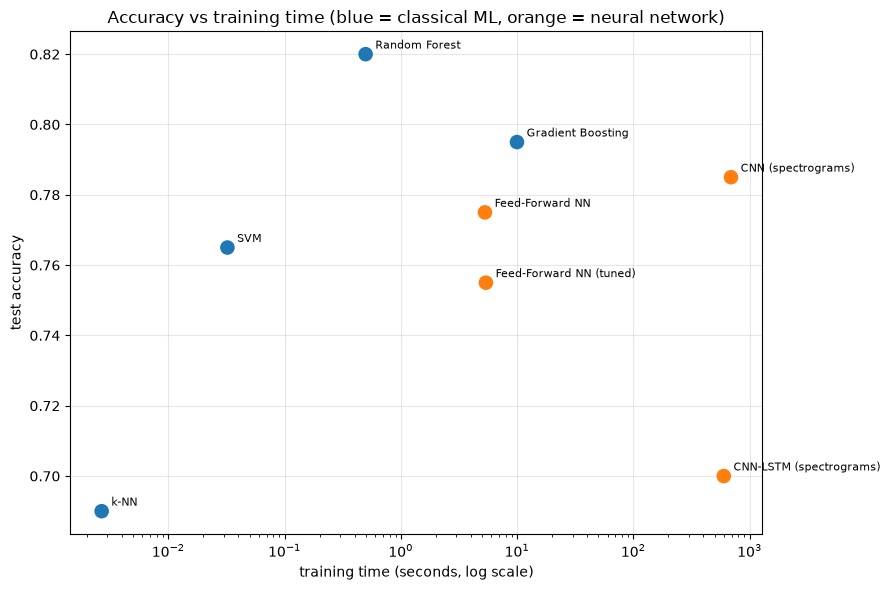

In [30]:
# 2.4.2.2. Accuracy against training cost, coloured by model family

fig, ax = plt.subplots(figsize=(9, 6))

# Map the Family column to colours so the classical/neural split is obvious
family_colors = results['Family'].map({'Classical ML': 'tab:blue',
                                       'Neural Network': 'tab:orange'})
ax.scatter(results['Training Time (s)'], results['Test Accuracy'],
           c=family_colors, s=90, zorder=3)

# Label each marker, offset a few points so the text clears the dot
for _, row in results.iterrows():
    ax.annotate(row['Model'], (row['Training Time (s)'], row['Test Accuracy']),
                textcoords='offset points', xytext=(7, 4), fontsize=8)

ax.set_xscale('log')    # times span 0.003 s to 607 s, so a linear axis is unreadable
ax.set_xlabel('training time (seconds, log scale)')
ax.set_ylabel('test accuracy')
ax.set_title('Accuracy vs training time (blue = classical ML, orange = neural network)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.4.2.3: Quantify to what extent test-set sampling noise was a factor:

In [31]:
# Quantify how much of the spread in the table is just test-set sampling noise

n_test = len(y_test)
p_hat = results['Test Accuracy'].max()                     # best observed accuracy
se = np.sqrt(p_hat * (1 - p_hat) / n_test)                 # binomial standard error

print(f'n_test = {n_test}')
print(f'best_accuracy = {p_hat:.4f}')
print(f'standard_error = {se:.4f}')
print(f'margin_95_percent = {1.96 * se:.4f}')

n_test = 200
best_accuracy = 0.8200
standard_error = 0.0272
margin_95_percent = 0.0532


### 2.4.3. Complexity:

Complexity column mixes decision nodes, support-vectors-times-features, stored samples and trainable parameters, so it is not a single scale.

Note that it is only comparable within a family, and not across different types of models.

### 2.4.4. Closing Discussion:

Within this dataset, neither added capacity nor synthetic variation made a significant improvement.

Random Forest trained in half a second remains the best model at 0.820

The binding constraint is the number of independent recordings rather than the sophistication of the architecture.